In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
zip_path = "/content/drive/MyDrive/breastcancerdetectml/ultrasounddataset.zip"
extract_path = "/content/ultrasounddataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [12]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/breastcancerdetectml/breast_cancer_cnn_final.keras")

print("Model loaded successfully!")

Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [14]:
IMG_SIZE = 128
threshold = 0.28328282

In [15]:
def predict_image(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Error loading:", img_path)
        return None, None

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized / 255.0

    img_input = np.reshape(img_normalized, (1, IMG_SIZE, IMG_SIZE, 3))

    prediction = model.predict(img_input)[0][0]

    if prediction > threshold:
        result = "MALIGNANT"
    else:
        result = "BENIGN"

    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.title(f"{result} ({prediction:.2f})")
    plt.axis('off')
    plt.show()

    return result, prediction

In [16]:
test_folder = "/content/drive/MyDrive/breastcancerdetectml/test_images"

Testing: malignant (14).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


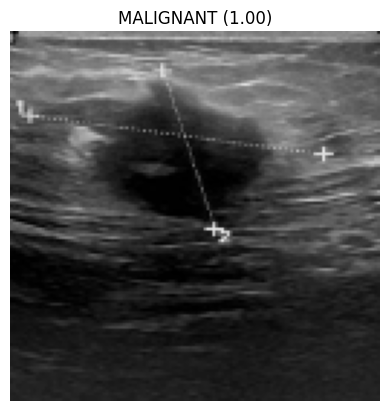

Prediction: MALIGNANT (1.00)
----------------------------------------
Testing: benign (12).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


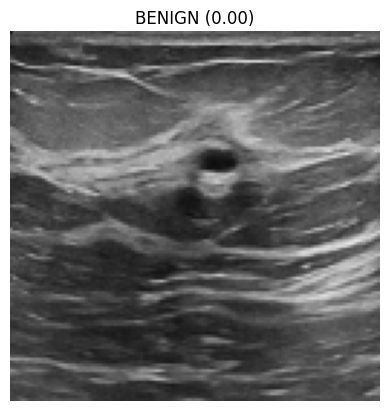

Prediction: BENIGN (0.00)
----------------------------------------


In [17]:
for img_name in os.listdir(test_folder):

    img_path = os.path.join(test_folder, img_name)

    print("Testing:", img_name)

    result, pred = predict_image(img_path)

    if result is not None:
        print(f"Prediction: {result} ({pred:.2f})")

    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


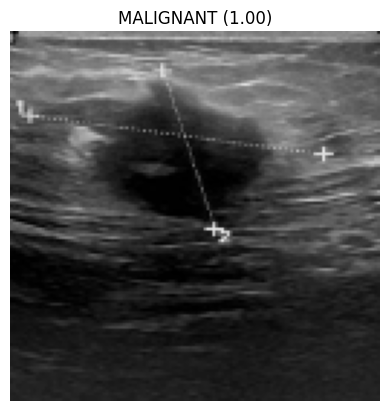

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


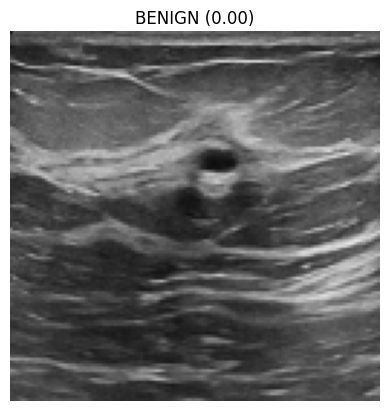

Final Results:
[('malignant (14).png', 'MALIGNANT', np.float32(0.99698335)), ('benign (12).png', 'BENIGN', np.float32(8.5328786e-11))]


In [18]:
results = []

for img_name in os.listdir(test_folder):

    img_path = os.path.join(test_folder, img_name)

    result, pred = predict_image(img_path)

    if result is not None:
        results.append((img_name, result, pred))

print("Final Results:")
print(results)